# Steerable Convolution on Tetris (Dense)

**6.7970/8.750 Symmetry and its Application to Machine Learning**

This notebook builds a **steerable $D_4$-equivariant CNN** using the dense approach: one call to `reduce_tensor_product` solves for all equivariant kernels at once. For the step-by-step version that enumerates each CG path, see the [companion notebook](steerable_tetris_paths.ipynb). Both notebooks use the same `SteerableConv2d` module — only the basis computation differs.

The key ideas:

1. Features are vectors of **irrep components** — starting as scalars ($A_1$) and getting **promoted** through tensor products.
2. The equivariant kernel basis is found by `reduce_tensor_product(rho_in, rho_spatial, rho_out)` — all valid CG couplings in one call.
3. The learned filter is a **linear combination** of these basis kernels — one scalar weight per solution per channel pair (**fully connected** over channels).
4. For images (fixed grid), the basis is precomputed once. For graphs (variable neighbors), you'd solve at runtime.

In [ ]:
%%capture
!pip install pymatgen
!pip install https://symm4ml.mit.edu/_static/symm4ml_s26/symm4ml/symm4ml_latest.zip

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from symm4ml import groups, rep, linalg
from symm4ml.group_conv import (
    apply_group_element_2D,
    image2D_permutation_representation,
)
from symm4ml.steerable import (
    spatial_basis_functions,
    steerable_kernel_basis_dense,
    irrep_content,
    content_norm_slices,
    norm_activation,
    SteerableConv2d,
)

torch.manual_seed(42)
np.random.seed(42)

---
## 1. $D_4$ Group and Irreps

In [2]:
# Generate D4
rot90 = np.array([[0., -1.], [1., 0.]])
sigma_v = np.array([[-1., 0.], [0., 1.]])
D4 = np.array(groups.generate_group(np.stack([sigma_v, rot90]))[::-1])
D4_table = groups.make_multiplication_table(D4)
D4_torch = torch.tensor(D4, dtype=torch.float32)

# Get irreps, replace E with geometric vec rep
np.random.seed(0)
D4_irreps = [np.array(ir).real for ir in rep.infer_irreps(D4_table)]
E_idx = next(i for i, ir in enumerate(D4_irreps) if ir.shape[1] == 2)
D4_irreps[E_idx] = D4.copy()

# Label 1D irreps from character table
dets = np.array([np.linalg.det(D4[g]) for g in range(len(D4))])
is_rot = dets > 0
irrep_labels = [None] * 5
for i, ir in enumerate(D4_irreps):
    if ir.shape[1] == 2:
        irrep_labels[i] = 'E'
    elif np.allclose(ir[:, 0, 0], 1):
        irrep_labels[i] = 'A1'
    elif np.allclose(ir[:, 0, 0][is_rot], 1):
        irrep_labels[i] = 'A2'
    elif ir[1, 0, 0] > 0:
        irrep_labels[i] = 'B1'
    else:
        irrep_labels[i] = 'B2'

A1 = irrep_labels.index('A1')
A2 = irrep_labels.index('A2')
B1 = irrep_labels.index('B1')
B2 = irrep_labels.index('B2')
E  = irrep_labels.index('E')

print(f'D4: {len(D4)} elements')
print(f'Irreps: {list(zip(irrep_labels, [ir.shape[1] for ir in D4_irreps]))}')

D4: 8 elements
Irreps: [('A1', 1), ('B2', 1), ('B1', 1), ('A2', 1), ('E', 2)]


---
## 2. Irrep Content and Block-Diagonal Representations

Features at each pixel are vectors of irrep components. The **irrep content** — how many copies of each irrep — is a hyperparameter.

We build **block-diagonal representation matrices** $\rho_{\text{in}}(g)$ and $\rho_{\text{out}}(g)$ from the irrep content. These describe how the group acts on the feature vectors.

In [3]:
# Define irrep content
scalar_content = [(A1, 1)]   # input: 1×A1 (scalar image)
hidden_content = [(A1, 1), (A2, 1), (B1, 1), (B2, 1), (E, 2)]  # 8-dim (= regular rep)

hidden_slices = content_norm_slices(hidden_content, D4_irreps)
hidden_dim = sum(d for _, _, d in hidden_slices)

# Build block-diagonal representations
n_g = len(D4)
rho_scalar = np.zeros((n_g, 1, 1))
for s, e, ir_idx, _, d in irrep_content(scalar_content, D4_irreps)[1]:
    rho_scalar[:, s:e, s:e] = D4_irreps[ir_idx]

rho_hidden = np.zeros((n_g, hidden_dim, hidden_dim))
for s, e, ir_idx, _, d in irrep_content(hidden_content, D4_irreps)[1]:
    rho_hidden[:, s:e, s:e] = D4_irreps[ir_idx]

print(f'Scalar rep: {rho_scalar.shape}')
print(f'Hidden rep: {rho_hidden.shape} (dim {hidden_dim})')
print(f'Hidden irrep blocks: {hidden_slices}')

Scalar rep: (8, 1, 1)
Hidden rep: (8, 8, 8) (dim 8)
Hidden irrep blocks: [(0, 1, 1), (1, 2, 1), (2, 3, 1), (3, 4, 1), (4, 6, 2), (6, 8, 2)]


---
## 3. Building Equivariant Filters from CG Coefficients

A steerable convolution couples three representations: **input features** (transforming as $\rho_{\text{in}}$), **spatial basis functions** on the pixel grid (transforming as the permutation representation $\Gamma^{\text{pix}}$), and **output features** (transforming as $\rho_{\text{out}}$). The tool for this coupling is `reduce_tensor_product` — which finds the **Clebsch–Gordan (CG) coefficients** that decompose the tensor product $\rho_{\text{in}} \otimes \Gamma^{\text{pix}}$ into components transforming as $\rho_{\text{out}}$.

Each solution $Q_w$ returned by `reduce_tensor_product` is an **equivariant kernel basis element**: a fixed $[d_{\text{out}}, d_{\text{in}}, n_{\text{pixels}}]$ tensor that, by construction, maps input features through spatial patterns to output features in a way that commutes with the group action. The most general equivariant filter is a **learned linear combination**:

$$K(\mathbf{y}) = \sum_{w=1}^{n_{\text{sol}}} \alpha_w \, Q_w(\mathbf{y})$$

where $n_{\text{sol}}$ is the number of independent CG paths and $\alpha_w$ are the learnable scalar weights — one per path per channel pair.

**Why is this equivariant?**

1. **Each CG path is equivariant.** The CG coefficients are a change of basis that decomposes the tensor product into irreps. If both inputs transform by $g$ (via $\rho_{\text{in}}(g)$ and $\Gamma^{\text{pix}}(g)$), the output transforms as $\rho_{\text{out}}(g)$ — this is the intertwining property that `reduce_tensor_product` always finds.

2. **Scalar combinations preserve equivariance.** If $Q_1$ and $Q_2$ are equivariant maps, then $\alpha_1 Q_1 + \alpha_2 Q_2$ is also equivariant. Schur's lemma tells us that a scalar weight per irrep block is the *only* freedom — so this parameterization is complete.

**Grid vs. graph.** On a **fixed grid** (like our $3 \times 3$ kernel), pixel positions are known at initialization. We precompute the basis elements once and store them — the forward pass is just a linear combination. On a **graph or point cloud**, neighbor positions vary per node, so the basis must be evaluated at runtime for each edge.

In [4]:
# Pixel permutation representation for 3×3 kernel
perm_rep = image2D_permutation_representation(D4_torch, [3, 3]).numpy()

# Decompose into irrep-labeled spatial basis functions
sp_basis = spatial_basis_functions(perm_rep, D4_irreps)

print("Spatial basis decomposition:")
for label, sb in zip(irrep_labels, sp_basis):
    if sb.shape[0] > 0:
        print(f"  {label}: {sb.shape[0]} copies × dim {sb.shape[1]}")
    else:
        print(f"  {label}: not present in 3×3 kernel")

# Solve for equivariant kernel basis (one call per layer)
lift_basis, d_in_lift, d_out_lift = steerable_kernel_basis_dense(
    D4_irreps, sp_basis, scalar_content, hidden_content)
conv_basis, d_in_conv, d_out_conv = steerable_kernel_basis_dense(
    D4_irreps, sp_basis, hidden_content, hidden_content)

print(f'\nLayer 1 (scalar → hidden): {lift_basis.shape[0]} basis kernels')
print(f'  → {lift_basis.shape[0]} learnable scalars per (c_out, c_in) pair')
print(f'Layer 2 (hidden → hidden): {conv_basis.shape[0]} basis kernels')
print(f'  → {conv_basis.shape[0]} learnable scalars per (c_out, c_in) pair')

Spatial basis decomposition:
  A1: 3 copies × dim 1
  B2: 1 copies × dim 1
  B1: 1 copies × dim 1
  A2: not present in 3×3 kernel
  E: 2 copies × dim 2

Layer 1 (scalar → hidden): 9 basis kernels
  → 9 learnable scalars per (c_out, c_in) pair
Layer 2 (hidden → hidden): 72 basis kernels
  → 72 learnable scalars per (c_out, c_in) pair


---
## 4. Model

Each `SteerableConv2d` stores the precomputed basis as a buffer and learns scalar weights. The weight tensor is `[c_out, c_in, n_basis]` — **fully connected** over channels (every output channel mixes all input channels), with the same basis elements for every channel pair.

**Activation**: We gate each irrep block using its **norm** (invariant under the group):

- **$A_1$ (trivial)**: `ReLU(x + b)` — pointwise, with learned bias on the scalar value.
- **Non-trivial irreps**: $\sigma(\|x\| + b) \cdot x / \|x\|$ — sigmoid on the norm (with learned bias on the norm), rescaled to preserve direction. The bias is on an **invariant scalar** (the norm), not on the feature vector itself.

In [6]:
# Convert basis to list of tensors for SteerableConv2d
lift_basis_list = [torch.tensor(lift_basis[i], dtype=torch.float32)
                   for i in range(lift_basis.shape[0])]
conv_basis_list = [torch.tensor(conv_basis[i], dtype=torch.float32)
                   for i in range(conv_basis.shape[0])]


class SteerableTetrisCNN(nn.Module):
    def __init__(self, c=8, num_classes=5):
        super().__init__()
        self.conv1 = SteerableConv2d(1, c, lift_basis_list, kernel_size=(3, 3))
        self.conv2 = SteerableConv2d(c, c, conv_basis_list, kernel_size=(3, 3))
        self.fc = nn.Linear(c, num_classes)
        self.hidden_slices = hidden_slices
        # One bias per irrep block: on scalar values for A1, on norms for others
        n_blocks = len(hidden_slices)
        self.act_bias1 = nn.Parameter(torch.zeros(n_blocks))
        self.act_bias2 = nn.Parameter(torch.zeros(n_blocks))

    def forward(self, x):
        x = x.unsqueeze(2)                              # add trivial irrep dim
        x = self.conv1(x)                               # scalar → hidden irreps
        x = norm_activation(x, self.hidden_slices, self.act_bias1)
        x = self.conv2(x)                               # hidden → hidden
        x = norm_activation(x, self.hidden_slices, self.act_bias2)
        x = x.mean(dim=(-2, -1))                        # spatial pool
        x = x[:, :, 0]                                  # A1 projection
        return self.fc(x)


model = SteerableTetrisCNN()
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Parameters: 4,737


---
## 5. Data and Training

In [7]:
PIECES = {
    'I': np.array([[-2, 0], [-1, 0], [0, 0], [1, 0]]),
    'O': np.array([[0, 0], [0, 1], [1, 0], [1, 1]]),
    'T': np.array([[0, -1], [0, 0], [0, 1], [1, 0]]),
    'S': np.array([[0, 0], [0, 1], [1, -1], [1, 0]]),
    'Z': np.array([[0, -1], [0, 0], [1, 0], [1, 1]]),
    'L': np.array([[-1, 0], [0, 0], [1, 0], [1, 1]]),
    'J': np.array([[-1, 0], [0, 0], [1, 0], [1, -1]]),
}
GRID_SIZE = 9
CENTER = GRID_SIZE // 2
MARGIN = 2  # keep pieces this far from grid boundary (matches conv receptive field)
D4_CLASSES = {'I': 0, 'O': 1, 'T': 2, 'S': 3, 'Z': 3, 'L': 4, 'J': 4}
D4_CLASS_NAMES = ['I', 'O', 'T', 'S/Z', 'L/J']


def place_piece(coords, grid_size=9, translation=None, margin=0):
    min_r, max_r = coords[:, 0].min(), coords[:, 0].max()
    min_c, max_c = coords[:, 1].min(), coords[:, 1].max()
    if translation is None:
        tr = np.random.randint(-min_r + margin, grid_size - max_r - margin)
        tc = np.random.randint(-min_c + margin, grid_size - max_c - margin)
    else:
        tr, tc = translation
    img = np.zeros((grid_size, grid_size))
    for r, c in coords:
        img[r + tr, c + tc] = 1.0
    return img


# Training: one centered image per class
seen, pieces = set(), []
for name in PIECES:
    if D4_CLASSES[name] not in seen:
        seen.add(D4_CLASSES[name]); pieces.append(name)
train_imgs = torch.tensor(
    np.array([place_piece(PIECES[n], GRID_SIZE, (CENTER, CENTER)) for n in pieces]),
    dtype=torch.float32).unsqueeze(1)
train_labels = torch.tensor([D4_CLASSES[n] for n in pieces], dtype=torch.long)

# Test: random D4 orientations and positions (with margin)
imgs, labels = [], []
for name, coords in PIECES.items():
    for _ in range(100):
        g = np.random.randint(len(D4))
        rotated = apply_group_element_2D(coords, D4[g])
        imgs.append(place_piece(rotated, GRID_SIZE, margin=MARGIN))
        labels.append(D4_CLASSES[name])
test_imgs = torch.tensor(np.array(imgs), dtype=torch.float32).unsqueeze(1)
test_labels = torch.tensor(labels, dtype=torch.long)

print(f'Training: {len(train_labels)} centered images ({pieces})')
print(f'Test: {len(test_labels)} images (random D4 transforms + positions, margin={MARGIN})')

Training: 5 centered images (['I', 'O', 'T', 'S', 'L'])
Test: 700 images (random D4 transforms + positions, margin=2)


## Note that **precision impacts** equivariance error. Let's look at the model before training in both `float32` and `float64`.

In [8]:
# Verify equivariance: an invariant model should produce identical logits
# for ALL D4 rotations/reflections of the same piece.
#                                                                                                        
# We compare model(g · image) vs model(image) for each group element g.
# Any difference is due to floating point arithmetic, not broken symmetry —                              
# the equivariance is exact in float64 (~1e-17) but float32 accumulates                                  
# errors across ~1152 multiply-adds per conv output element.                                             
                                                                                                       
torch.manual_seed(0)                                                                                     
model = SteerableTetrisCNN()                                                                             
model.eval()                                              
perm_full = image2D_permutation_representation(D4_torch, [GRID_SIZE, GRID_SIZE])
                                                                                                       
print("Equivariance check: max |model(g·image) - model(image)| over all g ∈ D4")                         
print("(should be ~1e-4 in float32, ~1e-17 in float64)\n")                                               
                                                                                                       
for name in ['T', 'L', 'S']:                              
  img = place_piece(PIECES[name], GRID_SIZE, (CENTER, CENTER))                                         
  img_t = torch.tensor(img, dtype=torch.float32).reshape(1, 1, GRID_SIZE, GRID_SIZE)                   
  with torch.no_grad():
      logits_orig = model(img_t)                                                                       
      max_diff = max(                                                                                  
          (model((perm_full[g] @ img_t.reshape(GRID_SIZE**2)).reshape(1,1,GRID_SIZE,GRID_SIZE))
           - logits_orig).abs().max().item()                                                           
          for g in range(8)                             
      )                                                                                                
  pred = D4_CLASS_NAMES[logits_orig.argmax(1).item()]   
  print(f'{name} → {pred}:  max logit diff = {max_diff:.2e}') 

Equivariance check: max |model(g·image) - model(image)| over all g ∈ D4
(should be ~1e-4 in float32, ~1e-17 in float64)

T → O:  max logit diff = 3.73e-09
L → O:  max logit diff = 1.04e-04
S → O:  max logit diff = 2.68e-05


In [9]:
# Same test in float64 to confirm the error is purely floating point precision.
# float64 has ~15 decimal digits vs float32's ~7 — the equivariance should
# be exact (limited only by float64 machine epsilon ~1e-16).

model_f64 = SteerableTetrisCNN().double()
model_f64.eval()
perm_full_f64 = perm_full.double()

print("Equivariance check in float64:\n")

for name in ['T', 'L', 'S']:
  img = place_piece(PIECES[name], GRID_SIZE, (CENTER, CENTER))
  img_t = torch.tensor(img, dtype=torch.float64).reshape(1, 1, GRID_SIZE, GRID_SIZE)
  with torch.no_grad():
      logits_orig = model_f64(img_t)
      max_diff = max(
          (model_f64((perm_full_f64[g] @ img_t.reshape(GRID_SIZE**2)).reshape(1,1,GRID_SIZE,GRID_SIZE))
           - logits_orig).abs().max().item()
          for g in range(8)
      )
  pred = D4_CLASS_NAMES[logits_orig.argmax(1).item()]
  print(f'{name} → {pred}:  max logit diff = {max_diff:.2e}')

print("\n→ Equivariance is exact — the ~1e-4 error in float32 is arithmetic")
print("  accumulation, not broken symmetry.")

Equivariance check in float64:

T → I:  max logit diff = 1.39e-17
L → I:  max logit diff = 1.39e-17
S → I:  max logit diff = 1.39e-17

→ Equivariance is exact — the ~1e-4 error in float32 is arithmetic
  accumulation, not broken symmetry.


## Now let's train

In [10]:
torch.manual_seed(0)
model = SteerableTetrisCNN()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
criterion = nn.CrossEntropyLoss()
history = {'loss': [], 'train_acc': [], 'test_acc': []}

for epoch in range(200):
    model.train()
    logits = model(train_imgs)
    loss = criterion(logits, train_labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        train_acc = (model(train_imgs).argmax(1) == train_labels).float().mean().item()
        test_acc = (model(test_imgs).argmax(1) == test_labels).float().mean().item()
    history['loss'].append(loss.item())
    history['train_acc'].append(train_acc)
    history['test_acc'].append(test_acc)

    if (epoch + 1) % 25 == 0:
        print(f'Epoch {epoch+1:3d}: loss={loss.item():.4f}  '
              f'train_acc={train_acc:.3f}  test_acc={test_acc:.3f}')

Epoch  25: loss=1.5103  train_acc=0.400  test_acc=0.429
Epoch  50: loss=1.1170  train_acc=1.000  test_acc=1.000
Epoch  75: loss=0.7609  train_acc=1.000  test_acc=1.000
Epoch 100: loss=0.5240  train_acc=1.000  test_acc=1.000
Epoch 125: loss=0.2952  train_acc=1.000  test_acc=1.000
Epoch 150: loss=0.1198  train_acc=1.000  test_acc=1.000
Epoch 175: loss=0.0520  train_acc=1.000  test_acc=1.000
Epoch 200: loss=0.0305  train_acc=1.000  test_acc=1.000


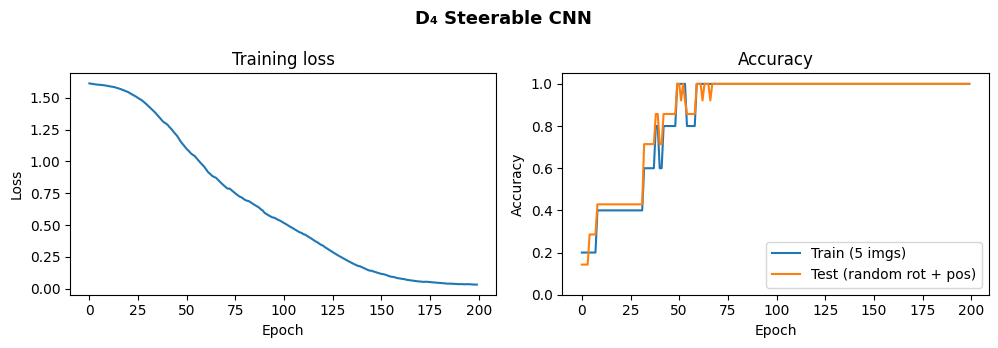

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))
ax1.plot(history['loss']); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Training loss')
ax2.plot(history['train_acc'], label=f'Train ({len(train_labels)} imgs)')
ax2.plot(history['test_acc'], label='Test (random rot + pos)')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.legend(); ax2.set_ylim(0, 1.05)
ax2.set_title('Accuracy')
fig.suptitle('D₄ Steerable CNN', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Verify Equivariance

In [14]:
# Verify equivariance AFTER training.
# The model output (logits) should be invariant: model(g · image) = model(image).
# Any difference is floating point arithmetic — the equivariance is exact in
# float64 (see above). In float32, the absolute error grows with training because
# the logits themselves grow (magnitude ~10), but the relative error stays ~1e-3.
                                                                                                       
model.eval()
perm_full = image2D_permutation_representation(D4_torch, [GRID_SIZE, GRID_SIZE])                         
                                                        
print("Equivariance after training: max |model(g·image) - model(image)| over g ∈ D4\n")                  

for name in ['T', 'L', 'S']:                                                                             
  img = place_piece(PIECES[name], GRID_SIZE, (CENTER, CENTER))
  img_t = torch.tensor(img, dtype=torch.float32).reshape(1, 1, GRID_SIZE, GRID_SIZE)                   
  with torch.no_grad():
      logits_orig = model(img_t)                                                                       
      max_diff = 0                                                                                     
      for g in range(8):
          img_flat = img_t.reshape(GRID_SIZE * GRID_SIZE)                                              
          img_rot = (perm_full[g] @ img_flat).reshape(1, 1, GRID_SIZE, GRID_SIZE)
          logits_rot = model(img_rot)                                                                  
          diff = (logits_rot - logits_orig).abs().max().item()
          max_diff = max(max_diff, diff)                                                               
  logit_mag = logits_orig.abs().max().item()                                                           
  pred = D4_CLASS_NAMES[logits_orig.argmax(1).item()]
  print(f'{name} → {pred}:  max diff = {max_diff:.2e}  (logit magnitude ~ {logit_mag:.1f}, relative error ~ {max_diff/logit_mag:.1e})')     

Equivariance after training: max |model(g·image) - model(image)| over g ∈ D4

T → T:  max diff = 1.91e-06  (logit magnitude ~ 5.7, relative error ~ 3.4e-07)
L → L/J:  max diff = 1.80e-02  (logit magnitude ~ 7.3, relative error ~ 2.5e-03)
S → S/Z:  max diff = 3.42e-03  (logit magnitude ~ 9.4, relative error ~ 3.6e-04)


---
## Summary

The steerable convolution pipeline:

1. **Choose irrep content** for each layer (the hyperparameter)
2. **Build block-diagonal reps** $\rho_{\text{in}}$, $\rho_{\text{out}}$ from irrep content
3. **Find equivariant kernels**: `reduce_tensor_product(rho_in, rho_spatial, rho_out)` $\to$ $n_{\text{sol}}$ basis elements
4. **Learn a linear combination**: one scalar weight per basis element per channel pair (fully connected)

| | Steerable CNN | Regular-rep group CNN |
|---|---|---|
| **Filter** | Scalar weights $\times$ fixed CG basis | Free weights on group $\times$ spatial grid |
| **Channels** | Fully connected; same basis for all channel pairs | Fully connected; same filter bank for all channels |
| **Nonlinearity** | Norm-based (bias on norm, not on features) | Pointwise ReLU (works because reg rep permutes) |
| **Precision** | Float-valued basis $\to$ ~1e-4 equivariance error in float32 | $D^{\text{reg}}$ is a permutation matrix $\to$ less accumulation |
| **Scales to $\text{SO}(3)$** | Yes (finite irrep truncation) | No (regular rep is $\infty$-dimensional) |